<a href="https://colab.research.google.com/github/muhfirdaus67a/analisis-sentimen-cukai/blob/main/Multinomial%20Naive%20Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

# 1. Load data
df = pd.read_csv("hasil_sentimen_fix2.csv", delimiter=';')

# 2. Bersihkan NaN
df['stemming'] = df['stemming'].fillna('').astype(str)

# 3. Vectorizer
vectorizer = CountVectorizer(ngram_range=(1,2))
X = vectorizer.fit_transform(df['stemming'])

# 4. Ambil daftar fitur
fitur = vectorizer.get_feature_names_out()

# 5. Pisahkan unigram & bigram
unigram = [f for f in fitur if len(f.split()) == 1]
bigram  = [f for f in fitur if len(f.split()) == 2]

# 6. Gabungkan: unigram dulu → bigram
fitur_urut = unigram + bigram

# 7. Simpan ke CSV
pd.DataFrame({"fitur": fitur_urut}).to_csv("fitur_unigram_bigram_urut.csv", index=False)

# 8. Hitung frekuensi sesuai urutan
frekuensi = np.asarray(X.sum(axis=0)).flatten()

# Buat dict fitur → frekuensi
freq_map = dict(zip(fitur, frekuensi))

# Urutkan mengikuti fitur_urut
frekuensi_urut = [freq_map[f] for f in fitur_urut]

# 9. Simpan fitur + frekuensi terurut
df_fitur = pd.DataFrame({
    "fitur": fitur_urut,
    "frekuensi": frekuensi_urut
})
df_fitur.to_csv("fitur_frekuensi_unigram_bigram_urut.csv", index=False)


# ***K-Fold***


================== FOLD 1 ==================

Distribusi Data:
         Train  Test
label               
Negatif     80    76
Positif    170   174
[[ 44  32]
 [ 11 163]]
TN: 44, FP: 32, FN: 11, TP: 163

================== FOLD 2 ==================

Distribusi Data:
         Train  Test
label               
Negatif     76    80
Positif    174   170
[[ 36  44]
 [  8 162]]
TN: 36, FP: 44, FN: 8, TP: 162

================== HASIL PER FOLD ==================
   Fold  Accuracy_Train  Accuracy_Test  Overfitting(%)  Precision  Recall  \
0     1            98.8           82.8            16.0      81.79   75.79   
1     2            99.6           79.2            20.4      80.23   70.15   

   F1-Score   TP  TN  FP  FN  
0     77.76  163  44  32  11  
1     72.12  162  36  44   8  

============= RATA-RATA METRIK K-FOLD =============
Rata-rata Akurasi Train : 99.20%
Rata-rata Akurasi Test  : 81.00%
Rata-rata Overfitting   : 18.20%
Rata-rata Precision     : 81.01%
Rata-rata Recall        : 72.97

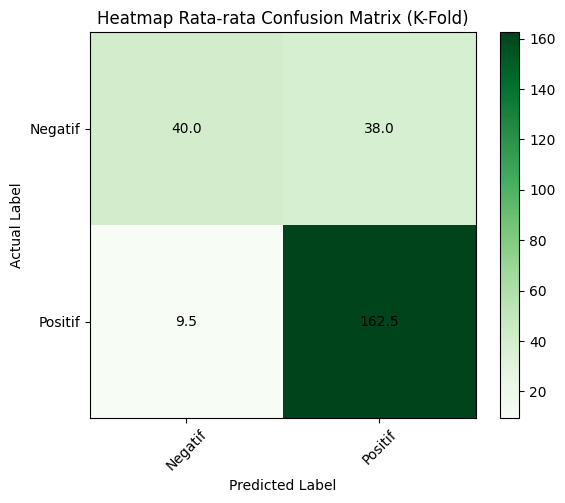

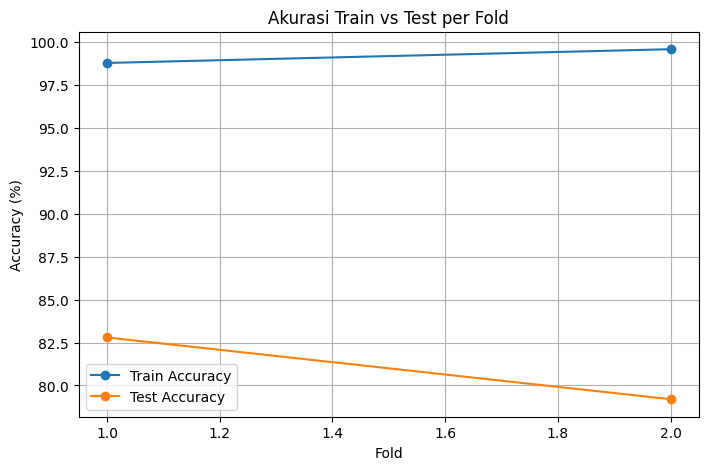

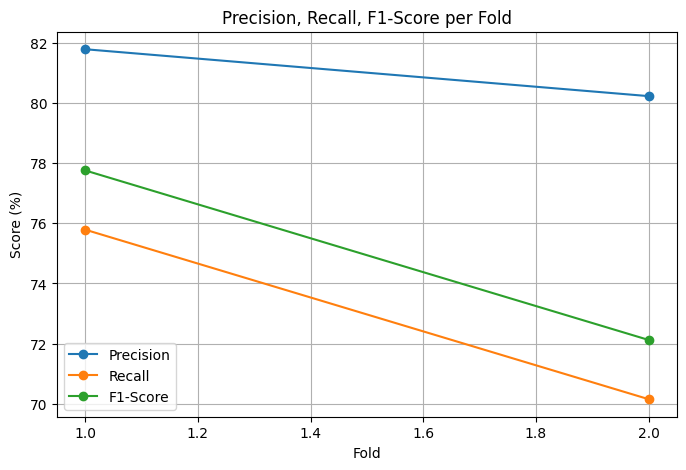

Jumlah data sebelum dropna: 500
Jumlah data sesudah dropna: 500


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# ======================= LOAD DATA =====================

df = pd.read_csv("hasil_sentimen_fix.csv", delimiter=';')
df = df[['stemming', 'label']].rename(columns={'stemming': 'text', 'label': 'label'})
df = df.dropna(subset=['text', 'label'])

labels = ['Negatif', 'Positif']
kf = KFold(n_splits= 2, shuffle=True, random_state=42)

fold_metrics = []
cm_list = []

# ====================== LOOP K-FOLD ====================

for fold, (train_idx, test_idx) in enumerate(kf.split(df), 1):

    df_train = df.iloc[train_idx]
    df_test = df.iloc[test_idx]

    print(f"\n================== FOLD {fold} ==================")

    # Distribusi data
    print("\nDistribusi Data:")
    train_dist = df_train['label'].value_counts()
    test_dist = df_test['label'].value_counts()
    distribusi_table = pd.DataFrame({"Train": train_dist, "Test": test_dist}).reindex(labels).fillna(0)
    print(distribusi_table)

    # Ekstraksi fitur
    vectorizer = CountVectorizer(ngram_range=(1,2))
    X_train = vectorizer.fit_transform(df_train['text'])
    X_test  = vectorizer.transform(df_test['text'])

    y_train = df_train['label']
    y_test  = df_test['label']

    # Train model
    model = MultinomialNB()
    model.fit(X_train, y_train)

    # Prediksi Train & Test
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test  = accuracy_score(y_test, y_pred_test)

    # Evaluasi
    precision = precision_score(y_test, y_pred_test, average="macro", zero_division=0)
    recall    = recall_score(y_test, y_pred_test, average="macro", zero_division=0)
    f1macro   = f1_score(y_test, y_pred_test, average="macro", zero_division=0)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred_test, labels=labels)
    cm_list.append(cm)

    tn, fp, fn, tp = cm.ravel()
    print(cm)
    print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")

    # Simpan metrik fold
    fold_metrics.append({
        "Fold": fold,
        "Accuracy_Train": round(acc_train * 100, 2),
        "Accuracy_Test": round(acc_test * 100, 2),
        "Overfitting(%)": round((acc_train - acc_test) * 100, 2),
        "Precision": round(precision * 100, 2),
        "Recall": round(recall * 100, 2),
        "F1-Score": round(f1macro * 100, 2),
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    })

# ======== KONVERSI HASIL PER FOLD KE DATAFRAME ========

df_metrics = pd.DataFrame(fold_metrics)
print("\n================== HASIL PER FOLD ==================")
print(df_metrics)

# ====== HEATMAP RATA-RATA CONFUSION MATRIX =============

# ================== RATA-RATA METRIK ===================

avg_accuracy_train = df_metrics["Accuracy_Train"].mean()
avg_accuracy_test  = df_metrics["Accuracy_Test"].mean()
avg_overfit        = df_metrics["Overfitting(%)"].mean()
avg_precision      = df_metrics["Precision"].mean()
avg_recall         = df_metrics["Recall"].mean()
avg_f1             = df_metrics["F1-Score"].mean()

print("\n============= RATA-RATA METRIK K-FOLD =============")
print(f"Rata-rata Akurasi Train : {avg_accuracy_train:.2f}%")
print(f"Rata-rata Akurasi Test  : {avg_accuracy_test:.2f}%")
print(f"Rata-rata Overfitting   : {avg_overfit:.2f}%")
print(f"Rata-rata Precision     : {avg_precision:.2f}%")
print(f"Rata-rata Recall        : {avg_recall:.2f}%")
print(f"Rata-rata F1-Score      : {avg_f1:.2f}%")

cm_avg = np.mean(cm_list, axis=0)

plt.figure(figsize=(6,5))
plt.imshow(cm_avg, interpolation='nearest', cmap="Greens")
plt.title("Heatmap Rata-rata Confusion Matrix (K-Fold)")
plt.colorbar()

tick_marks = range(len(labels))
plt.xticks(tick_marks, labels, rotation=45)
plt.yticks(tick_marks, labels)

# angka di kotak
for i in range(len(cm_avg)):
    for j in range(len(cm_avg)):
        plt.text(j, i, f"{cm_avg[i, j]:.1f}", ha='center', va='center')

plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

# Grafik Akurasi Train vs Test
plt.figure(figsize=(8,5))
plt.plot(df_metrics["Fold"], df_metrics["Accuracy_Train"], marker='o', label="Train Accuracy")
plt.plot(df_metrics["Fold"], df_metrics["Accuracy_Test"], marker='o', label="Test Accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy (%)")
plt.title("Akurasi Train vs Test per Fold")
plt.legend()
plt.grid(True)
plt.show()

# Grafik Precision, Recall, F1
plt.figure(figsize=(8,5))
plt.plot(df_metrics["Fold"], df_metrics["Precision"], marker='o', label="Precision")
plt.plot(df_metrics["Fold"], df_metrics["Recall"], marker='o', label="Recall")
plt.plot(df_metrics["Fold"], df_metrics["F1-Score"], marker='o', label="F1-Score")
plt.xlabel("Fold")
plt.ylabel("Score (%)")
plt.title("Precision, Recall, F1-Score per Fold")
plt.legend()
plt.grid(True)
plt.show()

print("Jumlah data sebelum dropna:", len(df))

df = df.dropna(subset=['text', 'label'])

print("Jumlah data sesudah dropna:", len(df))



In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

# Baca data
df = pd.read_csv("hasil_sentimen_fix.csv", delimiter=';')
df = df[['stemming', 'label']].rename(columns={'stemming': 'text', 'label': 'label'})
df = df.dropna(subset=['text', 'label'])

kf = KFold(n_splits=10, shuffle=True, random_state=42)

fold_metrics = []

for fold, (train_idx, test_idx) in enumerate(kf.split(df), 1):
    df_train = df.iloc[train_idx]
    df_test = df.iloc[test_idx]

    # === Ekstraksi fitur dengan unigram dan bigram ===
    vectorizer = CountVectorizer(ngram_range=(2, 2))
    X_train = vectorizer.fit_transform(df_train['text'])
    y_train = df_train['label']
    X_test = vectorizer.transform(df_test['text'])
    y_test = df_test['label']

    # Tampilkan hasil N-gram & Frekuensinya hanya pada Fold 1
    if fold == 1:
        # Ambil nama fitur
        feature_names = vectorizer.get_feature_names_out()

        # Pisahkan data latih berdasarkan kelas
        df_pos = df_train[df_train['label'] == 'Positif']
        df_neg = df_train[df_train['label'] == 'Negatif']

        # Transform masing-masing kelas
        X_pos = vectorizer.transform(df_pos['text'])
        X_neg = vectorizer.transform(df_neg['text'])

        # Hitung frekuensi fitur per kelas
        freq_pos = np.asarray(X_pos.sum(axis=0)).flatten()
        freq_neg = np.asarray(X_neg.sum(axis=0)).flatten()

        # Buat DataFrame frekuensi per kelas
        freq_class_df = pd.DataFrame({
            'Fitur': feature_names,
            'Frekuensi_Positif': freq_pos,
            'Frekuensi_Negatif': freq_neg
        })

        # Urutkan berdasarkan total frekuensi
        freq_class_df['Total_Frekuensi'] = (
            freq_class_df['Frekuensi_Positif'] + freq_class_df['Frekuensi_Negatif']
        )

        freq_class_df = freq_class_df.sort_values(
            by='Total_Frekuensi',
            ascending=False
        )

        # Tampilkan contoh
        print("\n=== Contoh Frekuensi Fitur Positif & Negatif (Fold 1) ===")
        print(freq_class_df.head(10))

        # Simpan untuk lampiran skripsi
        freq_class_df.to_csv(
            "frekuensi_fitur_positif_negatif_fold1.csv",
            index=False
        )


    # Latih model
    model = MultinomialNB()
    model.fit(X_train, y_train)

    # Prediksi data uji
    y_pred_test = model.predict(X_test)
    acc_test = accuracy_score(y_test, y_pred_test)
    prec = precision_score(y_test, y_pred_test, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred_test, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred_test, average='macro', zero_division=0)

    # Prediksi data latih (cek overfitting)
    y_pred_train = model.predict(X_train)
    acc_train = accuracy_score(y_train, y_pred_train)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_test)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
    else:
        tn = fp = fn = tp = None

    # Simpan hasil evaluasi
    fold_metrics.append({
        "Fold": fold,
        "Accuracy_Train": round(acc_train * 100, 2),
        "Accuracy_Test": round(acc_test * 100, 2),
        "Overfitting(%)": round((acc_train - acc_test) * 100, 2),
        "Precision": round(prec * 100, 2),
        "Recall": round(rec * 100, 2),
        "F1-Score": round(f1_macro * 100, 2),
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    })

# === Hasil evaluasi per fold ===
df_metrics = pd.DataFrame(fold_metrics)
print("\n=== Hasil Evaluasi per Fold ===")
print(df_metrics)

# === Rata-rata K-Fold ===
print("\n=== Rata-rata Hasil K-Fold ===")
print(df_metrics.drop(columns="Fold").mean(numeric_only=True))

print(df['label'].value_counts())



=== Contoh Frekuensi Fitur Positif & Negatif (Fold 1) ===
            Fitur  Frekuensi_Positif  Frekuensi_Negatif  Total_Frekuensi
1258  minum manis                 23                  5               28
17      air putih                 24                  3               27
1242    minum air                 16                  0               16
915    kena cukai                  3                  9               12
857    kalau tuju                 11                  0               11
2002  tuju banget                 10                  0               10
1919    tidak apa                  8                  1                9
1257    minum man                  6                  3                9
323    biar tidak                  7                  2                9
14    air mineral                  6                  3                9

=== Hasil Evaluasi per Fold ===
   Fold  Accuracy_Train  Accuracy_Test  Overfitting(%)  Precision  Recall  \
0     1           99.33     

Stratified

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Baca data
df = pd.read_csv("hasil_sentimen_fix.csv", delimiter=';')
df = df[['stemming', 'label']].rename(columns={'stemming': 'text', 'label': 'label'})
df = df.dropna(subset=['text', 'label'])

# Stratified K-Fold untuk menjaga proporsi kelas
n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

fold_metrics = []

for fold, (train_idx, test_idx) in enumerate(skf.split(df, df['label']), 1):
    df_train = df.iloc[train_idx]
    df_test = df.iloc[test_idx]

    vectorizer = CountVectorizer(ngram_range=(1,2))
    X_train = vectorizer.fit_transform(df_train['text'])
    y_train = df_train['label']
    X_test = vectorizer.transform(df_test['text'])
    y_test = df_test['label']

    # Latih model
    model = MultinomialNB()
    model.fit(X_train, y_train)

    # Prediksi
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    # Hitung metrik
    acc_test = accuracy_score(y_test, y_pred_test)
    acc_train = accuracy_score(y_train, y_pred_train)
    prec = precision_score(y_test, y_pred_test, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred_test, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred_test, average='macro', zero_division=0)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred_test)
    if cm.shape == (2,2):
        tn, fp, fn, tp = cm.ravel()
    else:
        tn = fp = fn = tp = None

    fold_metrics.append({
        "Fold": fold,
        "Accuracy_Train": round(acc_train*100, 2),
        "Accuracy_Test": round(acc_test*100, 2),
        "Overfitting(%)": round((acc_train-acc_test)*100, 2),
        "Precision": round(prec*100, 2),
        "Recall": round(rec*100, 2),
        "F1-Score": round(f1_macro*100, 2),
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "Jumlah_Uji": len(df_test)  # melihat jumlah data tiap fold
    })

# Tampilkan hasil
df_metrics = pd.DataFrame(fold_metrics)
print(df_metrics)
print("\nRata-rata 10-Fold:")
print(df_metrics.drop(columns="Fold").mean(numeric_only=True))


   Fold  Accuracy_Train  Accuracy_Test  Overfitting(%)  Precision  Recall  \
0     1           99.11           90.0            9.11      90.57   85.24   
1     2           98.89           80.0           18.89      79.13   70.48   
2     3           99.33           82.0           17.33      79.61   75.71   
3     4           99.11           78.0           21.11      75.00   69.05   
4     5           99.11           86.0           13.11      87.50   78.57   
5     6           99.11           90.0            9.11      90.57   85.24   
6     7           98.89           80.0           18.89      83.04   70.40   
7     8           99.56           82.0           17.56      84.69   73.53   
8     9           98.89           76.0           22.89      79.17   64.15   
9    10           99.11           78.0           21.11      81.23   67.28   

   F1-Score  TP  TN  FP  FN  Jumlah_Uji  
0     87.32  34  11   4   1          50  
1     72.59  33   7   8   2          50  
2     77.17  32   9   6   

In [ ]:
!pip install imbalanced-learn

*Borderline-SMOTE*

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import BorderlineSMOTE
import numpy as np
import matplotlib.pyplot as plt

# =======================
# BACA DATA
# =======================
df = pd.read_csv("hasil_sentimen_fix.csv", delimiter=';')
df = df[['stemming', 'label']].rename(columns={'stemming': 'text', 'label': 'label'})
df = df.dropna(subset=['text', 'label'])

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

fold_metrics = []
cms = []
labels_sorted = sorted(df['label'].str.lower().unique())

# =======================
# K-FOLD CV
# =======================
for fold, (train_idx, test_idx) in enumerate(kf.split(df, df['label']), 1):
    df_train = df.iloc[train_idx]
    df_test = df.iloc[test_idx]

    # === Ekstraksi fitur ===
    vectorizer = CountVectorizer(ngram_range=(1, 2))
    X_train = vectorizer.fit_transform(df_train['text'])
    X_test = vectorizer.transform(df_test['text'])

    # =======================
    # JUMLAH FITUR N-GRAM
    # =======================
    feature_names = vectorizer.get_feature_names_out()

    unigram_count = sum(1 for f in feature_names if len(f.split()) == 1)
    bigram_count = sum(1 for f in feature_names if len(f.split()) == 2)
    total_fitur = len(feature_names)

    print("Jumlah fitur Unigram :", unigram_count)
    print("Jumlah fitur Bigram  :", bigram_count)
    print("Jumlah fitur Total   :", total_fitur)

    # Label (dua versi!)
    y_train_series = df_train['label'].str.lower()   # pandas Series
    y_train = y_train_series.values                  # numpy array
    y_test = df_test['label'].str.lower()

    # =======================
    # Distribusi label awal
    # =======================
    print(f"\nFold {fold}")
    print("Distribusi label data latih:")
    print(y_train_series.value_counts())

    # =======================
    # HITUNG FITUR N-GRAM PER KELAS
    # =======================
    mask_pos = (y_train == 'positif')
    mask_neg = (y_train == 'negatif')

    X_pos = X_train[mask_pos]
    X_neg = X_train[mask_neg]

    freq_pos = np.asarray(X_pos.sum(axis=0)).ravel()
    freq_neg = np.asarray(X_neg.sum(axis=0)).ravel()

    jumlah_fitur_positif = (freq_pos > 0).sum()
    jumlah_fitur_negatif = (freq_neg > 0).sum()

    print("Jumlah fitur unik Positif :", jumlah_fitur_positif)
    print("Jumlah fitur unik Negatif :", jumlah_fitur_negatif)

    # =======================
    # BORDERLINE SMOTE
    # =======================
    smote = BorderlineSMOTE(random_state=42, kind='borderline-1')
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    print("\nDistribusi label setelah SMOTE:")
    print(pd.Series(y_train_res).value_counts())

    # Simpan data latih hasil SMOTE (fold 1 saja)
    if fold == 1:
        X_res_df = pd.DataFrame(
            X_train_res.toarray(),
            columns=vectorizer.get_feature_names_out()
        )
        X_res_df['label'] = y_train_res
        X_res_df.to_csv("data_latih_borderline_smote_fold1.csv", index=False)

    # =======================
    # TRAIN MODEL
    # =======================
    model = MultinomialNB()
    model.fit(X_train_res, y_train_res)

    # =======================
    # EVALUASI
    # =======================
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    acc_test = accuracy_score(y_test, y_pred_test)
    acc_train = accuracy_score(y_train, y_pred_train)

    prec = precision_score(y_test, y_pred_test, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred_test, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred_test, average='macro', zero_division=0)

    labels_sorted = sorted(df['label'].str.lower().unique())

    cm = confusion_matrix(y_test, y_pred_test, labels=labels_sorted)
    cms.append(cm)

    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
    else:
        tn = fp = fn = tp = None

    fold_metrics.append({
        "Fold": fold,
        "Accuracy_Train": round(acc_train * 100, 2),
        "Accuracy_Test": round(acc_test * 100, 2),
        "Overfitting(%)": round((acc_train - acc_test) * 100, 2),
        "Precision": round(prec * 100, 2),
        "Recall": round(rec * 100, 2),
        "F1-Score": round(f1_macro * 100, 2),
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    })

# =======================
# HASIL AKHIR
# =======================
df_metrics = pd.DataFrame(fold_metrics)

print("\n=== Hasil Tiap Fold ===")
print(df_metrics)

print("\n=== Rata-rata 10-Fold ===")
print(df_metrics.drop(columns="Fold").mean(numeric_only=True))


Jumlah fitur Unigram : 757
Jumlah fitur Bigram  : 2133
Jumlah fitur Total   : 2890

Fold 1
Distribusi label data latih:
label
positif    309
negatif    141
Name: count, dtype: int64
Jumlah fitur unik Positif : 1886
Jumlah fitur unik Negatif : 1296

Distribusi label setelah SMOTE:
positif    309
negatif    309
Name: count, dtype: int64
Jumlah fitur Unigram : 773
Jumlah fitur Bigram  : 2167
Jumlah fitur Total   : 2940

Fold 2
Distribusi label data latih:
label
positif    309
negatif    141
Name: count, dtype: int64
Jumlah fitur unik Positif : 1941
Jumlah fitur unik Negatif : 1292

Distribusi label setelah SMOTE:
positif    309
negatif    309
Name: count, dtype: int64
Jumlah fitur Unigram : 766
Jumlah fitur Bigram  : 2167
Jumlah fitur Total   : 2933

Fold 3
Distribusi label data latih:
label
positif    309
negatif    141
Name: count, dtype: int64
Jumlah fitur unik Positif : 1945
Jumlah fitur unik Negatif : 1284

Distribusi label setelah SMOTE:
positif    309
negatif    309
Name: count, dt


=== Distribusi Data pada Fold 1 ===
Data Latih (sebelum SMOTE):
label
Positif    309
Negatif    141
Name: count, dtype: int64
Data Latih (setelah SMOTE):
label
Positif    309
Negatif    309
Name: count, dtype: int64
Data Uji:
label
Positif    35
Negatif    15
Name: count, dtype: int64
--------------------------------------------

=== Distribusi Data pada Fold 2 ===
Data Latih (sebelum SMOTE):
label
Positif    309
Negatif    141
Name: count, dtype: int64
Data Latih (setelah SMOTE):
label
Positif    309
Negatif    309
Name: count, dtype: int64
Data Uji:
label
Positif    35
Negatif    15
Name: count, dtype: int64
--------------------------------------------

=== Distribusi Data pada Fold 3 ===
Data Latih (sebelum SMOTE):
label
Positif    309
Negatif    141
Name: count, dtype: int64
Data Latih (setelah SMOTE):
label
Positif    309
Negatif    309
Name: count, dtype: int64
Data Uji:
label
Positif    35
Negatif    15
Name: count, dtype: int64
--------------------------------------------

===

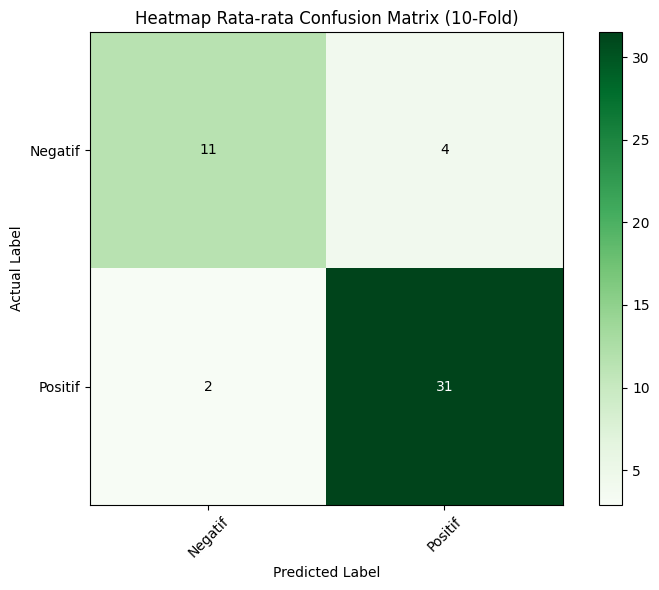

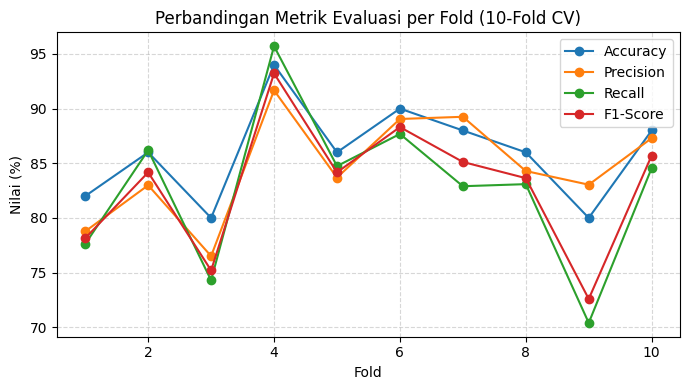

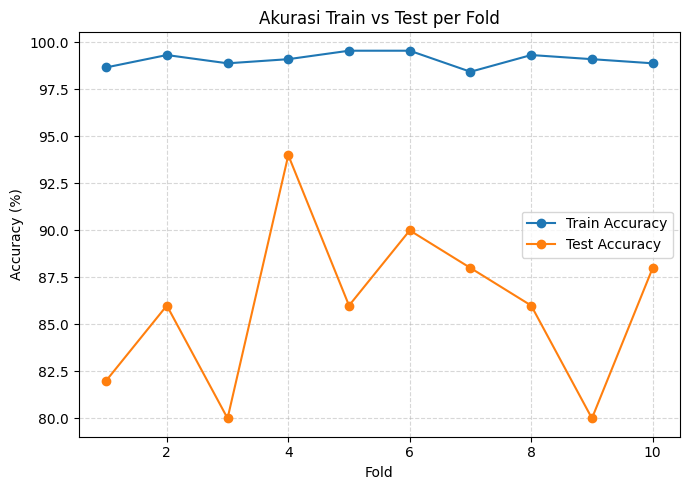

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import BorderlineSMOTE
import numpy as np
import matplotlib.pyplot as plt

# Baca data
df = pd.read_csv("hasil_sentimen_fix.csv", delimiter=';')
df = df[['stemming', 'label']].rename(columns={'stemming': 'text', 'label': 'label'})
df = df.dropna(subset=['text', 'label'])

kf = StratifiedKFold(n_splits= 10, shuffle=True, random_state=42)

fold_metrics = []
cms = []   # daftar confusion matrix untuk semua fold
labels_sorted = sorted(df['label'].unique())  # memastikan urutan kelas rapi

for fold, (train_idx, test_idx) in enumerate(kf.split(df, df['label']), 1):
    df_train = df.iloc[train_idx]
    df_test = df.iloc[test_idx]

    # === Ekstraksi fitur ===
    vectorizer = CountVectorizer (ngram_range=(1,2))
    X_train = vectorizer.fit_transform(df_train['text'])
    y_train = df_train['label']
    X_test = vectorizer.transform(df_test['text'])
    y_test = df_test['label']

    # === Borderline-SMOTE ===
    smote = BorderlineSMOTE(random_state=42, kind='borderline-1')
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    if fold == 1:
        X_res_df = pd.DataFrame(
            X_train_res.toarray(),
            columns=vectorizer.get_feature_names_out()
        )
        X_res_df['label'] = y_train_res.values

        X_res_df.to_csv("data_latih_borderline_smote_fold1.csv", index=False)
    # === Distribusi label sebelum & sesudah balancing ===
    print(f"\n=== Distribusi Data pada Fold {fold} ===")
    print("Data Latih (sebelum SMOTE):")
    print(y_train.value_counts())
    print("Data Latih (setelah SMOTE):")
    print(pd.Series(y_train_res).value_counts())
    print("Data Uji:")
    print(y_test.value_counts())
    print("--------------------------------------------")

    # === Latih model ===
    model = MultinomialNB()
    model.fit(X_train_res, y_train_res)

    # Prediksi data uji
    y_pred_test = model.predict(X_test)
    # === Simpan komentar + label aktual + prediksi per fold ===
    hasil_per_fold = pd.DataFrame({
        "Fold": fold,
        "Komentar": df_test["text"].values,
        "Label_Aktual": y_test.values,
        "Label_Prediksi": y_pred_test
    })

    # simpan semua fold ke list/df
    if fold == 1:
        semua_hasil = hasil_per_fold
    else:
        semua_hasil = pd.concat([semua_hasil, hasil_per_fold], ignore_index=True)

    acc_test = accuracy_score(y_test, y_pred_test)
    prec = precision_score(y_test, y_pred_test, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred_test, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred_test, average='macro', zero_division=0)

    # Prediksi data latih (cek overfitting)
    y_pred_train = model.predict(X_train)
    acc_train = accuracy_score(y_train, y_pred_train)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred_test, labels=labels_sorted)
    cms.append(cm)   # simpan confusion matrix per fold

    # Pisahkan binary atau bukan (opsional)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
    else:
        tn = fp = fn = tp = None

    # Simpan hasil
    fold_metrics.append({
        "Fold": fold,
        "Accuracy_Train": round(acc_train*100, 2),
        "Accuracy_Test": round(acc_test*100, 2),
        "Overfitting(%)": round((acc_train - acc_test)*100, 2),
        "Precision": round(prec*100, 2),
        "Recall": round(rec*100, 2),
        "F1-Score": round(f1_macro*100, 2),
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    })

# === Hasil akhir ===
df_metrics = pd.DataFrame(fold_metrics)
print("\n=== Hasil Tiap Fold ===")
print(df_metrics)

print("\n=== Rata-rata Hasil 10-Fold ===")
print(df_metrics.drop(columns="Fold").mean(numeric_only=True))
# === Simpan seluruh hasil ke CSV ===
semua_hasil.to_csv("hasil_prediksi_semua_fold.csv", index=False, encoding="utf-8-sig")

print("\nFile hasil prediksi berhasil disimpan sebagai: hasil_prediksi_semua_fold.csv")

# === HEATMAP CONFUSION MATRIX ===

cm_avg = np.mean(cms, axis=0)

print("\n=== Rata-rata Confusion Matrix (10-Fold) ===")
print(pd.DataFrame(cm_avg, columns=labels_sorted, index=labels_sorted))

plt.figure(figsize=(8,6))
plt.imshow(cm_avg, interpolation='nearest', cmap='Greens')
plt.title("Heatmap Rata-rata Confusion Matrix (10-Fold)")
plt.colorbar()

tick_marks = np.arange(len(labels_sorted))
plt.xticks(tick_marks, labels_sorted, rotation=45)
plt.yticks(tick_marks, labels_sorted)

# Angka di setiap sel
thresh = cm_avg.max() / 2
for i in range(cm_avg.shape[0]):
    for j in range(cm_avg.shape[1]):
        plt.text(j, i, format(int(cm_avg[i, j])),
                 ha="center", va="center",
                 color="white" if cm_avg[i, j] > thresh else "black")

plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

# --- Grafik Perbandingan Metrik (Accuracy, Precision, Recall, F1) ---
plt.figure(figsize=(7, 4))
plt.plot(df_metrics["Fold"], df_metrics["Accuracy_Test"], marker='o', label='Accuracy')
plt.plot(df_metrics["Fold"], df_metrics["Precision"], marker='o', label='Precision')
plt.plot(df_metrics["Fold"], df_metrics["Recall"], marker='o', label='Recall')
plt.plot(df_metrics["Fold"], df_metrics["F1-Score"], marker='o', label='F1-Score')
plt.xlabel("Fold")
plt.ylabel("Nilai (%)")
plt.title("Perbandingan Metrik Evaluasi per Fold (10-Fold CV)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# --- Grafik Akurasi Train vs Test ---
plt.figure(figsize=(7,5))
plt.plot(df_metrics["Fold"], df_metrics["Accuracy_Train"], marker='o', label='Train Accuracy')
plt.plot(df_metrics["Fold"], df_metrics["Accuracy_Test"], marker='o', label='Test Accuracy')
plt.xlabel("Fold")
plt.ylabel("Accuracy (%)")
plt.title("Akurasi Train vs Test per Fold")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

RUS

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from imblearn.under_sampling import RandomUnderSampler
import numpy as np

df = pd.read_csv("hasil_sentimen.csv", delimiter=';')
df = df[['hasil_preprocessing', 'label']].rename(columns={'hasil_preprocessing': 'text', 'label': 'label'})
df = df.dropna(subset=['text', 'label'])

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

max_features_list = [700]  # Coba beberapa nilai max_features

for max_feat in max_features_list:
    print(f"\n=== Evaluasi dengan max_features = {max_feat} ===")
    accuracies = []
    f1_scores_macro = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(df, df['label']), 1):
        df_train = df.iloc[train_idx]
        df_test = df.iloc[test_idx]

        vectorizer = CountVectorizer(ngram_range=(1, 2), max_features=max_feat)
        X_train = vectorizer.fit_transform(df_train['text'])
        y_train = df_train['label']
        X_test = vectorizer.transform(df_test['text'])
        y_test = df_test['label']

        # Terapkan undersampling
        rus = RandomUnderSampler(random_state=42)
        X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

        model = MultinomialNB(alpha=1.5)
        model.fit(X_train_resampled, y_train_resampled)

        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
        accuracies.append(acc)
        f1_scores_macro.append(f1_macro)

        print(f"\n--- Fold {fold} ---")
        print(classification_report(y_test, y_pred, zero_division=0))

    print(f"\nRata-rata Accuracy untuk max_features={max_feat}: {np.mean(accuracies):.4f}")
    print(f"Rata-rata F1-Score Macro untuk max_features={max_feat}: {np.mean(f1_scores_macro):.4f}")

    y_train_pred = model.predict(X_train)
accuracy_train = accuracy_score(y_train, y_train_pred)
print("Accuracy on training data:", accuracy_train)



=== Evaluasi dengan max_features = 700 ===

--- Fold 1 ---
              precision    recall  f1-score   support

     Negatif       0.75      1.00      0.86        15
     Positif       1.00      0.86      0.92        35

    accuracy                           0.90        50
   macro avg       0.88      0.93      0.89        50
weighted avg       0.93      0.90      0.90        50


--- Fold 2 ---
              precision    recall  f1-score   support

     Negatif       0.62      0.87      0.72        15
     Positif       0.93      0.77      0.84        35

    accuracy                           0.80        50
   macro avg       0.78      0.82      0.78        50
weighted avg       0.84      0.80      0.81        50


--- Fold 3 ---
              precision    recall  f1-score   support

     Negatif       0.85      0.73      0.79        15
     Positif       0.89      0.94      0.92        35

    accuracy                           0.88        50
   macro avg       0.87      0.84   

SMOTE

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
import numpy as np

df = pd.read_csv("hasil_sentimen_fix.csv", delimiter=';')
df = df[['stemming', 'label']].rename(columns={'stemming': 'text', 'label': 'label'})
df = df.dropna(subset=['text', 'label'])

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

accuracies = []
f1_scores_macro = []

for fold, (train_idx, test_idx) in enumerate(kf.split(df, df['label']), 1):
    df_train = df.iloc[train_idx]
    df_test = df.iloc[test_idx]

    vectorizer = CountVectorizer(max_features=700, ngram_range=(1, 2))
    X_train = vectorizer.fit_transform(df_train['text'])
    y_train = df_train['label']
    X_test = vectorizer.transform(df_test['text'])
    y_test = df_test['label']

    # Terapkan SMOTE untuk oversampling kelas minoritas di data training
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    model = MultinomialNB()
    model.fit(X_train_resampled, y_train_resampled)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    accuracies.append(acc)
    f1_scores_macro.append(f1_macro)

    print(f"\n=== Evaluasi Fold {fold} ===")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred, labels=['Negatif', 'Positif'])
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
    else:
        tn = fp = fn = tp = 0

    print("--- Confusion Matrix ---")
    print(f"TP (Positif diklasifikasi positif): {tp}")
    print(f"TN (Negatif diklasifikasi negatif): {tn}")
    print(f"FP (Negatif diklasifikasi positif): {fp}")
    print(f"FN (Positif diklasifikasi negatif): {fn}")

print("\n=== Rata-rata Hasil 10-Fold ===")
print(f"Average Accuracy       : {np.mean(accuracies):.4f}")
print(f"Average F1-Score Macro : {np.mean(f1_scores_macro):.4f}")

# Misal X_train, y_train sudah disiapkan dan model sudah fit
y_train_pred = model.predict(X_train)
accuracy_train = accuracy_score(y_train, y_train_pred)
print("Accuracy on training data:", accuracy_train)



=== Evaluasi Fold 1 ===
              precision    recall  f1-score   support

     Negatif       0.81      0.87      0.84        15
     Positif       0.94      0.91      0.93        35

    accuracy                           0.90        50
   macro avg       0.88      0.89      0.88        50
weighted avg       0.90      0.90      0.90        50

--- Confusion Matrix ---
TP (Positif diklasifikasi positif): 32
TN (Negatif diklasifikasi negatif): 13
FP (Negatif diklasifikasi positif): 2
FN (Positif diklasifikasi negatif): 3

=== Evaluasi Fold 2 ===
              precision    recall  f1-score   support

     Negatif       0.56      0.60      0.58        15
     Positif       0.82      0.80      0.81        35

    accuracy                           0.74        50
   macro avg       0.69      0.70      0.70        50
weighted avg       0.75      0.74      0.74        50

--- Confusion Matrix ---
TP (Positif diklasifikasi positif): 28
TN (Negatif diklasifikasi negatif): 9
FP (Negatif dik

BorderLine SMOTE

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import BorderlineSMOTE
import numpy as np

# Baca data
df = pd.read_csv("hasil_sentimen_fix.csv", delimiter=';')
df = df[['stemming', 'label']].rename(columns={'stemming': 'text', 'label': 'label'})
df = df.dropna(subset=['text', 'label'])

kf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

fold_metrics = []

for fold, (train_idx, test_idx) in enumerate(kf.split(df, df['label']), 1):
    df_train = df.iloc[train_idx]
    df_test = df.iloc[test_idx]

    # === Ekstraksi fitur ===
    vectorizer = CountVectorizer(ngram_range=(1,2))
    X_train = vectorizer.fit_transform(df_train['text'])
    y_train = df_train['label']
    X_test = vectorizer.transform(df_test['text'])
    y_test = df_test['label']

    # === Borderline-SMOTE ===
    smote = BorderlineSMOTE(random_state=42, kind='borderline-1')
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # === Distribusi label sebelum & sesudah balancing ===
    print(f"\n=== Distribusi Data pada Fold {fold} ===")
    print("Data Latih (sebelum SMOTE):")
    print(y_train.value_counts())
    print("Data Latih (setelah SMOTE):")
    print(pd.Series(y_train_res).value_counts())
    print("Data Uji:")
    print(y_test.value_counts())
    print("--------------------------------------------")

    # === Latih model ===
    model = MultinomialNB()
    model.fit(X_train_res, y_train_res)

    # Prediksi data uji
    y_pred_test = model.predict(X_test)
    acc_test = accuracy_score(y_test, y_pred_test)
    prec = precision_score(y_test, y_pred_test, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred_test, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred_test, average='macro', zero_division=0)

    # Prediksi data latih (cek overfitting)
    y_pred_train = model.predict(X_train)
    acc_train = accuracy_score(y_train, y_pred_train)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred_test)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
    else:
        tn = fp = fn = tp = None

    # Simpan hasil
    fold_metrics.append({
        "Fold": fold,
        "Accuracy_Train": round(acc_train*100, 2),
        "Accuracy_Test": round(acc_test*100, 2),
        "Overfitting(%)": round((acc_train - acc_test)*100, 2),
        "Precision": round(prec*100, 2),
        "Recall": round(rec*100, 2),
        "F1-Score": round(f1_macro*100, 2),
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    })

# === Hasil akhir ===
df_metrics = pd.DataFrame(fold_metrics)
print("\n=== Hasil Tiap Fold ===")
print(df_metrics)

print("\n=== Rata-rata Hasil 5-Fold ===")
print(df_metrics.drop(columns="Fold").mean(numeric_only=True))



=== Distribusi Data pada Fold 1 ===
Data Latih (sebelum SMOTE):
label
Positif    173
Negatif     77
Name: count, dtype: int64
Data Latih (setelah SMOTE):
label
Negatif    173
Positif    173
Name: count, dtype: int64
Data Uji:
label
Positif    173
Negatif     77
Name: count, dtype: int64
--------------------------------------------

=== Distribusi Data pada Fold 2 ===
Data Latih (sebelum SMOTE):
label
Positif    173
Negatif     77
Name: count, dtype: int64
Data Latih (setelah SMOTE):
label
Positif    173
Negatif    173
Name: count, dtype: int64
Data Uji:
label
Positif    173
Negatif     77
Name: count, dtype: int64
--------------------------------------------

=== Hasil Tiap Fold ===
   Fold  Accuracy_Train  Accuracy_Test  Overfitting(%)  Precision  Recall  \
0     1            99.2           81.2            18.0      77.93   78.13   
1     2            99.6           84.0            15.6      81.60   80.15   

   F1-Score   TP  TN  FP  FN  
0     78.03  149  54  23  24  
1     80.80  

Smote Tomek

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from imblearn.combine import SMOTETomek
import numpy as np

# Baca dataset
df = pd.read_csv("hasil_sentimen.csv", delimiter=';')
df = df[['hasil_preprocessing', 'label']].rename(columns={'hasil_preprocessing': 'text', 'label': 'label'})
df = df.dropna(subset=['text', 'label'])

X_text = df['text']
y = df['label']

# Stratified K-Fold menjaga proporsi kelas
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

accuracies = []
f1_scores_macro = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_text, y), 1):
    X_train_text, X_test_text = X_text.iloc[train_idx], X_text.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # CountVectorizer dengan N-gram (unigram + bigram)
    vectorizer = CountVectorizer(max_features=700, ngram_range=(1,2))
    X_train = vectorizer.fit_transform(X_train_text)
    X_test = vectorizer.transform(X_test_text)

    # SMOTETomek untuk oversampling + pembersihan data minoritas
    smote_tomek = SMOTETomek(random_state=42)
    X_train_resampled, y_train_resampled = smote_tomek.fit_resample(X_train, y_train)

    # Train model Multinomial Naive Bayes
    model = MultinomialNB()
    model.fit(X_train_resampled, y_train_resampled)

    # Prediksi data test
    y_pred = model.predict(X_test)

    # Evaluasi
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    accuracies.append(acc)
    f1_scores_macro.append(f1_macro)

    print(f"\n=== Evaluasi Fold {fold} ===")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred, labels=['Negatif', 'Positif'])
    if cm.shape == (2,2):
        tn, fp, fn, tp = cm.ravel()
    else:
        tn = fp = fn = tp = 0

    print("--- Confusion Matrix ---")
    print(f"TP (Positif diklasifikasi positif): {tp}")
    print(f"TN (Negatif diklasifikasi negatif): {tn}")
    print(f"FP (Negatif diklasifikasi positif): {fp}")
    print(f"FN (Positif diklasifikasi negatif): {fn}")

# Rata-rata hasil 10-Fold
print("\n=== Rata-rata Hasil 10-Fold ===")
print(f"Average Accuracy       : {np.mean(accuracies):.4f}")
print(f"Average F1-Score Macro : {np.mean(f1_scores_macro):.4f}")

# Evaluasi pada training data terakhir (opsional)
y_train_pred = model.predict(X_train)
accuracy_train = accuracy_score(y_train, y_train_pred)
print("Accuracy on training data:", accuracy_train)



=== Evaluasi Fold 1 ===
              precision    recall  f1-score   support

     Negatif       0.78      0.93      0.85        15
     Positif       0.97      0.89      0.93        35

    accuracy                           0.90        50
   macro avg       0.87      0.91      0.89        50
weighted avg       0.91      0.90      0.90        50

--- Confusion Matrix ---
TP (Positif diklasifikasi positif): 31
TN (Negatif diklasifikasi negatif): 14
FP (Negatif diklasifikasi positif): 1
FN (Positif diklasifikasi negatif): 4

=== Evaluasi Fold 2 ===
              precision    recall  f1-score   support

     Negatif       0.70      0.93      0.80        15
     Positif       0.97      0.83      0.89        35

    accuracy                           0.86        50
   macro avg       0.83      0.88      0.85        50
weighted avg       0.89      0.86      0.86        50

--- Confusion Matrix ---
TP (Positif diklasifikasi positif): 29
TN (Negatif diklasifikasi negatif): 14
FP (Negatif di